<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/03_Transfer_Learning_for_Classifying_200_types_of_Bird_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Transfer learning implementation - 200 type of birds with Pytorch**

---

**Context**

In this tutorial, we will build a neural network model to classify 200 types of birds. We will use transfer learning mechanism to shorten the training process.

**Transfer learning**

Transfer learning is a machine learning paradigm where a model trained on one task (typically with large-scale data) is reused, adapted, or fine-tuned for a different but related task.

![image](https://towardsdatascience.com/wp-content/uploads/2020/07/1cY9AOTe3vjlerL73ItnfTg.jpeg)

**CUB-200-2011 Dataset**

The CUB-200-2011 (Caltech-UCSD Birds) dataset contains images of 200 bird species with detailed annotations, making it suitable for tasks where classes are visually similar and require subtle feature discrimination.


Key Characteristics

- Number of classes: 200 bird species  
- Total images: 11,788  
- Training images: 5,994  
- Testing images: 5,794  
- Image source: Mostly collected from Flickr  

**Initial setup**

In [1]:
# Importing libraries
from torchvision import models # Torchvision provides models for transfer learning
from torch import nn


In [2]:
# Defining our model with resnet18 and we will use weight from imagenet datasets
model = models.resnet18(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


In [3]:
# Convert the 'head' of resnet18 from linear layer with 1000 inputs into 200 inputs
# We define nn.linear with the size of feature
num_ftr = model.fc.in_features
model.fc = nn.Linear(num_ftr, 200)

In [4]:
# We will freeze some parts of model and unfreeze some parts of them

# Firstly, we will freeze all model
model.train(False)
# Then, we will unfreeze only the 'head' of the model
model.fc.train(True)

Linear(in_features=512, out_features=200, bias=True)

In [5]:
# Installing gdown to download dataset
!pip install gdown

In [6]:
# Downloading dataset from gdrive
!gdown --fuzzy https://drive.google.com/file/d/1XBneW9_JmaD_DmilLKDnGwqzzetJoCrj/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1XBneW9_JmaD_DmilLKDnGwqzzetJoCrj
From (redirected): https://drive.google.com/uc?id=1XBneW9_JmaD_DmilLKDnGwqzzetJoCrj&confirm=t&uuid=559a8151-9c6e-4b05-ace6-e5d608ec6192
To: /content/CUB_200_2011.tgz
100% 1.15G/1.15G [00:17<00:00, 66.2MB/s]


In [7]:
# Extracting dataset
!tar -xf ./CUB_200_2011.tgz

In [8]:
# Importing libraries for pytorch
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import seaborn as sns
plt.ion()

In [9]:
# This code will process the downloaded files (images and labels.txt) into structured image folders
# That have been divided by each class

# The structured folders will be:
# bird_species 1\
#   image1
#   image2

read_line = open('./CUB_200_2011/train_test_split.txt')
a = read_line.readlines()
classes = open('./CUB_200_2011/classes.txt')
c_names = classes.readlines()
len(c_names)
for i in range(len(c_names)):
    c_names[i] = c_names[i].split(' ')[1]

import os
for i in range(len(c_names)):
    os.makedirs('./test/'+c_names[i].split('\n')[0], exist_ok=True)

train_dataset = datasets.ImageFolder('./CUB_200_2011/images')
from skimage import io

for j in range(len(train_dataset.imgs)):
    if(a[j].split(' ')[1].split('\n')[0] == '0'):
        path = train_dataset.imgs[j][0]
        img = io.imread(path)
        folder = train_dataset.imgs[j][0].split('/')[3]
        img_name = train_dataset.imgs[j][0].split('/')[4]
        io.imsave('./test/'+folder+'/'+img_name,img)
        os.remove(path)


In [10]:
# Creating a train folder
!mkdir train
# Moving images into train folder
!cp -r ./CUB_200_2011/images/* ./train/

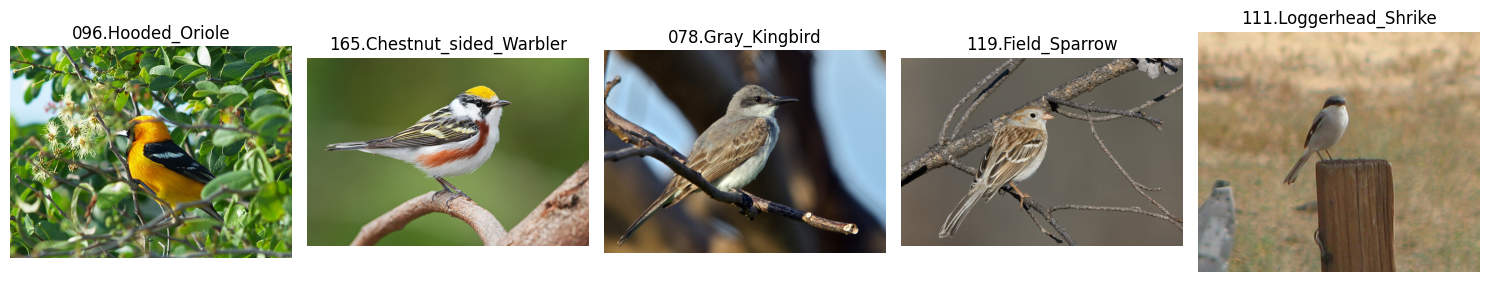

In [11]:
# display 5 images from train
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

# Path to the training data directory
train_data_dir = './train'

# Get a list of all image paths in the training directory
all_image_paths = []
for root, _, files in os.walk(train_data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(os.path.join(root, file))

# Select 5 random images
if len(all_image_paths) < 5:
    print(f"Warning: Only {len(all_image_paths)} images found. Displaying all available.")
    images_to_display = all_image_paths
else:
    images_to_display = random.sample(all_image_paths, 5)

# Display the images
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(images_to_display):
    plt.subplot(1, len(images_to_display), i + 1)
    image = Image.open(img_path)
    plt.imshow(image)
    plt.title(os.path.basename(os.path.dirname(img_path)))
    plt.axis('off')

plt.tight_layout()
plt.show()


**Data Preprocessing**

In [12]:
# Data preprocessing
# Image augmentation (Only for training data)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomRotation(45),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '.'
# loading datasets with PyTorch ImageFolder
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'test']}
# defining data loaders to load data using image_datasets and transforms, here we also specify batch size for the mini batch
dataloders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=8,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

use_gpu = torch.cuda.is_available()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [13]:
# displaying sizes
print(dataset_sizes)

{'train': 5994, 'test': 5794}


In [14]:
# We make a new bird folder
!mkdir Bird

**Model training**

In [15]:
# Defining model training function
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = model.state_dict()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                #scheduler.step()
                model.train(True)  # Set model to training mode
            else:
                model.train(False)  # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for data in dataloders[phase]:
                # get the inputs
                inputs, labels = data

                # wrap them in Variable
                if use_gpu:
                    inputs = Variable(inputs.cuda())
                    labels = Variable(labels.cuda())
                else:
                    inputs, labels = Variable(inputs), Variable(labels)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                outputs = model(inputs)

                _, preds = torch.max(outputs.data, 1)
                loss = criterion(outputs, labels)

                # backward + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # statistics
                running_loss += loss.data
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                state = {'model':model.state_dict(),'optim':optimizer_ft.state_dict()}
                torch.save(state,'./Bird/point_resnet_best.pth')

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best test Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [16]:
if use_gpu:                                 # if gpu is available then use it
    model = model.cuda()
#model_ft = model_ft.float()
criterion = nn.CrossEntropyLoss()           # defining loss function

# Observe that all parameters are being optimized
optimizer_ft = optim.Adam(model.parameters(), lr=0.0001)

In [17]:
# Model training
model = train_model(model, criterion, optimizer_ft,num_epochs=50)

Epoch 0/49
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train Loss: 0.5743 Acc: 0.0891
test Loss: 0.3798 Acc: 0.2986

Epoch 1/49
----------
train Loss: 0.4306 Acc: 0.2611
test Loss: 0.2686 Acc: 0.4646

Epoch 2/49
----------
train Loss: 0.3627 Acc: 0.3727
test Loss: 0.2136 Acc: 0.5435

Epoch 3/49
----------
train Loss: 0.3141 Acc: 0.4341
test Loss: 0.2016 Acc: 0.5632

Epoch 4/49
----------
train Loss: 0.2809 Acc: 0.4975
test Loss: 0.1694 Acc: 0.6269

Epoch 5/49
----------
train Loss: 0.2587 Acc: 0.5250
test Loss: 0.1649 Acc: 0.6293

Epoch 6/49
----------
train Loss: 0.2370 Acc: 0.5646
test Loss: 0.1524 Acc: 0.6540

Epoch 7/49
----------
train Loss: 0.2223 Acc: 0.5861
test Loss: 0.1587 Acc: 0.6479

Epoch 8/49
----------
train Loss: 0.2108 Acc: 0.5993
test Loss: 0.1493 Acc: 0.6679

Epoch 9/49
----------
train Loss: 0.1984 Acc: 0.6221
test Loss: 0.1404 Acc: 0.6931

Epoch 10/49
----------
train Loss: 0.1891 Acc: 0.6386
test Loss: 0.1349 Acc: 0.7021

Epoch 11/49
----------
train Loss: 0.1843 Acc: 0.6456
test Loss: 0.1430 Acc: 0.6886

Epoch 12/49


In [18]:
# Other metrics evaluation
# Precision # Recall # F1 score

import torch
import torchvision.transforms as transforms
from torchvision import datasets
from sklearn.metrics import precision_score, recall_score, f1_score

device = 'cuda' if use_gpu else 'cpu'

# Function to calculate precision, recall, and F1 score
def calculate_metrics(model, dataloader):
    model.eval()
    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    precision = precision_score(true_labels, predicted_labels, average="macro")
    recall = recall_score(true_labels, predicted_labels, average="macro")
    f1 = f1_score(true_labels, predicted_labels, average="macro")

    return precision, recall, f1

# Calculate metrics on test set
precision, recall, f1 = calculate_metrics(model, dataloders['test'])
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Precision: 0.7193
Recall: 0.6946
F1 Score: 0.6927
